# mistsim vs Raul: normalisation, epoch and conventions

Re-runs the comparison of `raul_comparison.ipynb` against Raul
Monsalve's 2026 test simulations with the current mistsim/croissant
(croissant v5.3.0.dev3), and tests the differences between mistsim and
Raul's simulator that his 2022 code
(`MIST-Experiment/raul_global21cm/astro.py` @ `4c2d125`) makes
visible. MISTIC analysis queue item **S9**.

Raul's tests (`data/2026021{5,20}_for_christian`, read in place):

| Test | Site | Blockage |
|---|---|---|
| 0 | MARS spot 2 (79.418 N, 90.748 W, 150 m) | 10 deg at all AZ |
| 1 | MARS spot 2 | none |
| 2 | North Pole (0 m) | none |

All: Haslam (Remazeilles 2014) degraded to nside 128, scaled with
beta = -2.55 above T_CMB; FEKO beam
`beam_best_fit_meas_39_joint_wide.out`, dipole along N-S; 40-125 MHz
at 1 MHz; 241 LSTs at 6-min steps.

**Sections**
1. Setup and Raul's inputs: his time grid is reconstructed exactly.
2. Runs: mistsim variants and a pixel-domain replica of Raul's
   `convolution`.
3. The data first: Raul's and mistsim's waterfalls and spectra.
4. Residuals per test, before and after.
5. Normalisation: what mistsim divides by, and Test 0 vs Test 1.
6. Conventions: beam azimuth direction and the horizon mask under
   `beam_az_rot` (synthetic test).
7. Residual budget and summary (also in `NORMALIZATION_REPORT.md`).

Residuals are always **mistsim - Raul** in K.

In [1]:
import os

# Keep CPU use moderate: another analysis may share the machine.
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault(
    "XLA_FLAGS",
    "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=4",
)

import importlib.metadata as md
import json
import subprocess
import sys
import time
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import astropy
import astropy.units as u
import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astropy.utils import iers

import mistsim as ms

# Raul's epoch (2014) is covered by the bundled IERS-B table; never
# download.
iers.conf.auto_download = False

%matplotlib inline


def find_repo_root(start=None, marker="pyproject.toml"):
    here = Path(start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"no {marker} above {here}")


REPO = find_repo_root()
sys.path.insert(0, str(REPO / "notebooks/sim_comparisons"))
import raul_tools as rt  # noqa: E402

# Raul's data are untracked; read them in place (read-only), from
# this checkout's data/ or the shared checkout next to it.
DATA_DIR = rt.find_data_dir(REPO)
RES = REPO / "notebooks/sim_comparisons/results_normalization"
CACHE = RES / "cache"  # *.npz, git-ignored
CACHE.mkdir(parents=True, exist_ok=True)
FORCE = False  # recompute cached runs

NSIDE = 128
LMAX = 100
TESTS = {
    0: "Test 0: MARS, 10 deg blockage",
    1: "Test 1: MARS, no blockage",
    2: "Test 2: North Pole, no blockage",
}


def git(*args):
    return subprocess.run(
        ["git", "-C", str(REPO), *args], capture_output=True, text=True
    ).stdout.strip()


cro_url = json.loads(
    md.distribution("croissant-sim").read_text("direct_url.json")
)
PROV = {
    "mistsim_commit": git("rev-parse", "--short", "HEAD"),
    "mistsim_branch": git("rev-parse", "--abbrev-ref", "HEAD"),
    "croissant": cro_url["vcs_info"].get("requested_revision"),
    "croissant_commit": cro_url["vcs_info"]["commit_id"][:7],
    "jax": jax.__version__,
    "astropy": astropy.__version__,
    "healpy": hp.__version__,
    "python": sys.version.split()[0],
    "data_dir": str(DATA_DIR),
    "lmax": LMAX,
    "nside": NSIDE,
}
for k, v in PROV.items():
    print(f"{k:18s} {v}")

mistsim_commit     4d12bfd
mistsim_branch     notebooks/raul-comparison-normalization
croissant          v5.3.0.dev3
croissant_commit   58bf56e
jax                0.11.1
astropy            7.2.0
healpy             1.19.0
python             3.13.12
data_dir           /home/christian/Documents/research/MIST/mistsim/data
lmax               100
nside              128


## 1. Raul's inputs

**Time grid.** Raul's 2022 `galactic_to_local_coordinates_24h_LST`
(astro.py:625) starts at UTC 2014-01-01 09:29:45 (LST = 0 h at EDGES),
steps 359 s, takes `ceil(86164/359) = 241` steps, labels each with
the apparent sidereal time (`utc2lst`: IAU2006A, DUT1 = 0) and sorts by
LST. Rebuilding that grid at each test site reproduces the `lst` arrays
of his 2026 files to machine precision, so his 2026 code used the same
grid: **the epoch is 2014-01-01**. `raul_comparison.ipynb` instead
placed the LSTs on 2022-07-17 using mean sidereal time.

In [2]:
paths = {
    0: "20260215_for_christian/antenna_temperature_20260215_test1.hdf5",
    1: "20260220_for_christian/antenna_temperature_20260220_test1.hdf5",
    2: "20260220_for_christian/antenna_temperature_20260220_test2.hdf5",
}
raul, lsts, locs, utc, order = {}, {}, {}, {}, {}
freqs = None
for k, rel in paths.items():
    lst_k, f_k, t_k = rt.read_raul(DATA_DIR / rel)
    freqs = f_k if freqs is None else freqs
    assert np.allclose(f_k, freqs)
    raul[k], lsts[k] = t_k, lst_k
    locs[k] = rt.location(k)
    utc[k], lst_mine, order[k] = rt.raul_times(locs[k].lon.deg)
    err = np.max(np.abs(lst_mine[order[k]] - lst_k))
    print(f"{TESTS[k]:34s} max |LST_rebuilt - LST_Raul| = {err:.1e} h")
    assert err < 1e-9
# The UTC sample times are the same for all three tests.
assert all(np.allclose(utc[k].jd, utc[0].jd) for k in TESTS)
print(f"UTC {utc[0][0].iso} .. {utc[0][-1].iso}, {len(utc[0])} steps")

Test 0: MARS, 10 deg blockage      max |LST_rebuilt - LST_Raul| = 5.5e-14 h
Test 1: MARS, no blockage          max |LST_rebuilt - LST_Raul| = 5.5e-14 h
Test 2: North Pole, no blockage    max |LST_rebuilt - LST_Raul| = 5.7e-14 h
UTC 2014-01-01 09:29:45.000 .. 2014-01-02 09:25:45.000, 241 steps


**Beam.** `data/feko_beam.npz` is the total gain of Raul's FEKO file.
Check it against the `.out` file at three frequencies (the parser
reads the far-field tables; it scans the 470 MB file once).

In [3]:
def read_feko_gain(path, want_hz):
    # Total gain (dB column) on theta 0..90, phi 0..359 at want_hz.
    out, cur, rows, reading = {}, None, [], False
    with open(path) as f:
        for line in f:
            if "Frequency in Hz" in line and "FREQ =" in line:
                cur = float(line.split("=")[1])
            elif cur in want_hz and "THETA    PHI" in line:
                reading, rows = True, []
            elif reading:
                p = line.split()
                if len(p) < 10:
                    if rows:
                        out[cur], reading = np.array(rows), False
                        if len(out) == len(want_hz):
                            break
                    continue
                rows.append([float(p[0]), float(p[1]), float(p[8])])
    gains = {}
    for fr, arr in out.items():
        th, ph, gdb = arr.T
        g = np.zeros((91, 360))
        g[th.astype(int), ph.astype(int)] = np.where(
            gdb < -900, 0.0, 10 ** (gdb / 10)
        )
        gains[fr] = g
    return gains


gain, theta_full, gain_above, theta, phi = rt.feko_beam_full(
    DATA_DIR / "feko_beam.npz", freqs
)
feko = read_feko_gain(
    DATA_DIR
    / "20260215_for_christian/beam_best_fit_meas_39_joint_wide.out",
    {40e6, 80e6, 125e6},
)
beam_check = {}
for fr, g in sorted(feko.items()):
    i = int(np.argmin(np.abs(freqs - fr / 1e6)))
    rel = np.max(np.abs(gain_above[i] - g)) / g.max()
    # symmetry of the beam: phi -> phi + 180 and phi -> -phi
    a180 = np.max(np.abs(g - np.roll(g, 180, 1))) / g.max()
    amir = np.max(np.abs(g - g[:, (-np.arange(360)) % 360])) / g.max()
    beam_check[f"{fr / 1e6:.0f}MHz"] = {
        "max_rel_diff_npz_vs_out": float(rel),
        "asym_phi_plus_180": float(a180),
        "asym_phi_minus_phi": float(amir),
    }
    print(f"{fr / 1e6:5.0f} MHz: npz vs .out {rel:.1e}; asymmetry "
          f"phi+180 {a180:.1e}, phi->-phi {amir:.1e} (of peak)")

   40 MHz: npz vs .out 9.6e-101; asymmetry phi+180 4.3e-05, phi->-phi 2.3e-05 (of peak)
   80 MHz: npz vs .out 2.4e-101; asymmetry phi+180 2.8e-04, phi->-phi 2.0e-04 (of peak)
  125 MHz: npz vs .out 1.2e-101; asymmetry phi+180 1.5e-03, phi->-phi 1.6e-03 (of peak)


In [4]:
sky = rt.load_haslam(
    DATA_DIR / "20260215_for_christian/haslam408_ds_Remazeilles2014.fits",
    NSIDE,
    freqs,
)
sky_model = ms.Sky(sky, freqs, sampling="healpix", coord="galactic")

thd = np.rad2deg(theta_full)
# mistsim's horizon masks are booleans on the beam's theta rows.
# "le80": theta <= 80 deg, as raul_comparison.ipynb (and the
# pipeline's horizon_max_theta) builds it. On the 1-deg mwss grid the
# theta = 80 row stands for 79.5-80.5 deg, so the effective edge is
# near 80.5 deg. "half" gives that row weight 0.5 (edge ~80 deg).
HORIZON = {
    "le80": (thd <= 80 + 1e-9)[:, None],
    "half": np.where(
        thd < 80 - 1e-9, 1.0, np.where(np.isclose(thd, 80), 0.5, 0.0)
    )[:, None],
}
# Raul maps FEKO phi straight onto astronomical AZ (N through E).
# mistsim with beam_az_rot = 0 puts phi = 0 at North and phi = 90 at
# West (section 6), the mirror image. Feeding mistsim gain(-phi)
# reproduces Raul's orientation.
gain_mirror = gain[:, :, (-np.arange(360)) % 360]

## 2. Runs

Each run is cached in `results_normalization/cache/` (git-ignored). A from-scratch execution takes about 30 min on 4 cores (peak ~11 GB RAM, during the `niter=3` sky transform); the committed outputs come from re-executing the notebook on the cache that run wrote, so the cells report no compute times.

**mistsim variants** (all `lmax = 100`, `beam_az_rot = 0` unless
noted). Each step of the ladder adds one change to the one above:

| key | times | normalisation | beam | Test 0 mask |
|---|---|---|---|---|
| `base` | 2022-07-17, mean LST (as `raul_comparison.ipynb`) | above-horizon | as is | `le80` |
| `epoch` | Raul's UTC grid (2014-01-01) | above-horizon | as is | `le80` |
| `mirror` | Raul's | above-horizon | gain(-phi) | `le80` |
| `edge` | Raul's | above-horizon | gain(-phi) | `half` |
| `lmax179` | Raul's | above-horizon | gain(-phi) | `half`, lmax 179 |
| `niter3` | Raul's | above-horizon | gain(-phi) | `half`; sky SHT with healpix `niter=3` |

plus `edge_lt80` on Test 0 (gain(-phi), mask theta < 80 deg, i.e. the
theta = 80 row blocked: effective edge near 79.5 deg), which brackets
the edge from the other side.

and, for the normalisation test, on Test 0 with Raul's times:
`full_sphere` (Tgnd = 0, no correction: what `Simulator.sim` with
`Tgnd=0` and the pipeline's `simulate_waterfall` give) and `default`
(`Simulator.sim` with mistsim's default `Tgnd = 300 K`).

**Pixel replica** (`pix`): Raul's `convolution` re-implemented in
`raul_tools.py`: astropy galactic to AltAz for every pixel and time,
bicubic `RectBivariateSpline` of the beam in (EL, AZ) without AZ wrap,
sum(B T m) / sum(B m) over EL >= 0 with m = (EL >= 10 deg) for Test 0;
`pix_mirror` uses AZ = -phi instead.

In [5]:
def cached(key, fn):
    path = CACHE / f"{key}.npz"
    if path.exists() and not FORCE:
        z = np.load(path)
        return {n: z[n] for n in z.files}
    t0 = time.time()
    out = fn()
    np.savez(path, **out)
    print(f"  {key}: computed in {time.time() - t0:.0f} s")
    return out


def lst_to_time_2022(lst_arr, loc):
    # raul_comparison.ipynb's mapping: mean LST on 2022-07-17.
    t0 = Time("2022-07-17 00:00", location=loc)
    lst_ref = t0.sidereal_time("mean").hour
    return t0 + (lst_arr - lst_ref) / 24 * u.sday


SKY_ALM = {}


def sky_alm_for(times_jd):
    # Sky alm in CIRS at times_jd[0]; location-independent.
    key = round(float(times_jd[0]), 9)
    if key not in SKY_ALM:
        SKY_ALM[key] = rt.precompute_sky_alm(
            sky_model, freqs, times_jd, gain
        )
    return SKY_ALM[key]


SKY_ALM_NITER3 = {}


def sky_alm_niter3(times_jd):
    # Same frame, but the HEALPix SHT iterated 3 times.
    key = round(float(times_jd[0]), 9)
    if key not in SKY_ALM_NITER3:
        csky = cro.Sky(sky, freqs, sampling="healpix", coord="galactic",
                       niter=3)
        b = ms.Beam(gain, freqs, sampling="mwss")
        s0 = ms.Simulator(b, sky_model, times_jd, freqs, 0.0, 0.0,
                          lmax=LMAX, Tgnd=0.0)
        SKY_ALM_NITER3[key] = csky.compute_alm_eq(
            world="earth", et=s0.et_ref
        )
    return SKY_ALM_NITER3[key]


def ms_run(k, times_jd, reorder, g, hor, lmax=LMAX, norm="above_horizon",
           niter3=False):
    def fn():
        salm = (sky_alm_niter3 if niter3 else sky_alm_for)(times_jd)
        tant, fg = rt.run_mistsim(
            g, freqs, sky_model, times_jd, locs[k],
            horizon=hor, lmax=lmax, normalization=norm, sky_alm=salm,
        )
        if reorder is not None:
            tant = tant[reorder]
        return {"tant": tant, "fgnd": fg}
    return fn


runs, fgnd = {}, {}
for k in TESTS:
    hor_le80 = HORIZON["le80"] if k == 0 else None
    hor_half = HORIZON["half"] if k == 0 else None
    t22 = lst_to_time_2022(lsts[k], locs[k])
    ladder = {
        "base": ms_run(k, t22.jd, None, gain, hor_le80),
        "epoch": ms_run(k, utc[k].jd, order[k], gain, hor_le80),
        "mirror": ms_run(k, utc[k].jd, order[k], gain_mirror, hor_le80),
        "edge": ms_run(k, utc[k].jd, order[k], gain_mirror, hor_half),
        "lmax179": ms_run(
            k, utc[k].jd, order[k], gain_mirror, hor_half, lmax=179
        ),
        "niter3": ms_run(
            k, utc[k].jd, order[k], gain_mirror, hor_half, niter3=True
        ),
    }
    if k != 0:
        ladder.pop("edge")  # no mask edge without blockage
    if k == 0:
        ladder["edge_lt80"] = ms_run(
            k, utc[k].jd, order[k], gain_mirror,
            (thd < 80 - 1e-9)[:, None],
        )
        for norm in ("full_sphere", "default"):
            ladder[norm] = ms_run(
                k, utc[k].jd, order[k], gain, hor_le80, norm=norm
            )
    for name, fn in ladder.items():
        out = cached(f"ms_{name}_test{k}", fn)
        runs[(k, name)] = out["tant"]
        fgnd[(k, name)] = out["fgnd"]
    print(f"{TESTS[k]}: {sorted(n for (kk, n) in runs if kk == k)}")

Test 0: MARS, 10 deg blockage: ['base', 'default', 'edge', 'edge_lt80', 'epoch', 'full_sphere', 'lmax179', 'mirror', 'niter3']
Test 1: MARS, no blockage: ['base', 'epoch', 'lmax179', 'mirror', 'niter3']
Test 2: North Pole, no blockage: ['base', 'epoch', 'lmax179', 'mirror', 'niter3']


In [6]:
spl = rt.beam_splines(gain_above, np.rad2deg(theta), np.rad2deg(phi))
spl_m = rt.beam_splines(
    gain_above, np.rad2deg(theta), np.rad2deg(phi), mirror=True
)


def pix_run(k):
    def fn():
        az, el = rt.pixel_altaz(NSIDE, locs[k], utc[k][order[k]])
        el_min = 10.0 if k == 0 else 0.0
        return {
            "pix": rt.pixel_convolution(spl, sky, az, el, el_min),
            "pix_mirror": rt.pixel_convolution(
                spl_m, sky, az, el, el_min
            ),
            "check": np.array(
                rt.check_pixel_convolution(spl, sky, az, el, el_min, n=1)
            ),
        }
    return fn


for k in TESTS:
    out = cached(f"pix_test{k}", pix_run(k))
    runs[(k, "pix")] = out["pix"]
    runs[(k, "pix_mirror")] = out["pix_mirror"]
    print(f"{TESTS[k]}: fast vs direct spline evaluation "
          f"{float(out['check']):.1e} K")

Test 0: MARS, 10 deg blockage: fast vs direct spline evaluation 4.5e-12 K
Test 1: MARS, no blockage: fast vs direct spline evaluation 3.6e-12 K
Test 2: North Pole, no blockage: fast vs direct spline evaluation 5.5e-12 K


## 3. The data first

Raul's antenna temperature for the three tests, then Raul and mistsim
spectra at four LSTs. The mistsim curve is the `epoch` run: current
mistsim with Raul's time grid and the above-horizon normalisation,
otherwise as `raul_comparison.ipynb`. At this scale the two cannot be
told apart; the residuals follow.

At the North Pole the spectra at LST 0 and 12 h (and at 6 and 18 h)
coincide, as they must for a two-fold-symmetric dipole rotating about
the pole.

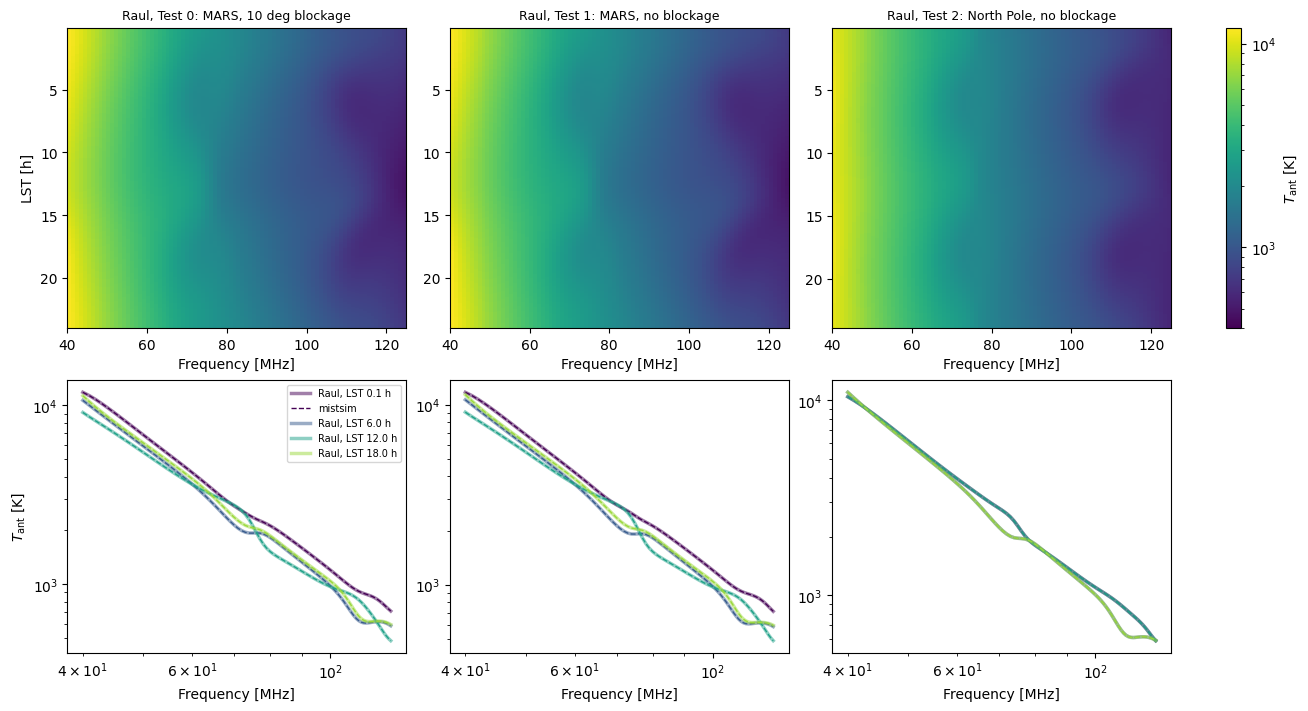

In [7]:
FIG_DPI = 90


def savefig(fig, name):
    fig.savefig(RES / name, dpi=FIG_DPI, bbox_inches="tight")


fig, axs = plt.subplots(
    2, 3, figsize=(13, 7), constrained_layout=True,
    gridspec_kw={"height_ratios": [1.1, 1]},
)
show_lsts = [0.0, 6.0, 12.0, 18.0]
colors = plt.cm.viridis(np.linspace(0, 0.85, len(show_lsts)))
for j, k in enumerate(TESTS):
    ext = [freqs[0], freqs[-1], lsts[k][-1], lsts[k][0]]
    im = axs[0, j].imshow(
        raul[k], extent=ext, aspect="auto", interpolation="none",
        norm=plt.matplotlib.colors.LogNorm(400, 12000),
    )
    axs[0, j].set_title(f"Raul, {TESTS[k]}", fontsize=9)
    axs[0, j].set_xlabel("Frequency [MHz]")
    for c, L in zip(colors, show_lsts):
        i = int(np.argmin(np.abs(lsts[k] - L)))
        axs[1, j].loglog(freqs, raul[k][i], color=c, lw=2.5, alpha=0.5,
                         label=f"Raul, LST {lsts[k][i]:.1f} h")
        axs[1, j].loglog(freqs, runs[(k, "epoch")][i], color=c, ls="--",
                         lw=1, label="mistsim" if L == 0 else None)
    axs[1, j].set_xlabel("Frequency [MHz]")
axs[0, 0].set_ylabel("LST [h]")
axs[1, 0].set_ylabel(r"$T_{\rm ant}$ [K]")
axs[1, 0].legend(fontsize=7)
fig.colorbar(im, ax=axs[0, :], label=r"$T_{\rm ant}$ [K]")
savefig(fig, "fig1_data_waterfalls_spectra.png")
plt.show()

## 4. Residuals per test

In [8]:
def stats(k, name, ref=None):
    ref = raul[k] if ref is None else ref
    d = runs[(k, name)] - ref
    s = rt.residual_stats(d)
    i, j = np.unravel_index(np.argmax(np.abs(d)), d.shape)
    s["argmax_lst_h"] = float(lsts[k][i])
    s["argmax_freq_MHz"] = float(freqs[j])
    s["rel_mean_abs"] = float(np.mean(np.abs(d)) / np.mean(raul[k]))
    # effective time lag: least-squares d ~ a * dT/dLST
    dT = np.gradient(raul[k], lsts[k] * 3600, axis=0)  # K per LST s
    a = float(np.sum(d * dT) / np.sum(dT * dT))
    s["lag_fit_s"] = a  # seconds of LST (sidereal)
    s["rms_after_lag_fit_K"] = float(np.sqrt(np.mean((d - a * dT) ** 2)))
    return s


ORDER = ["base", "epoch", "mirror", "edge", "edge_lt80", "lmax179",
         "niter3", "pix", "pix_mirror"]
summary = {}
hdr = (f"{'variant':12s} {'mean':>7s} {'rms':>7s} {'mean|d|':>8s} "
       f"{'max|d|':>7s} {'at LST,MHz':>12s} {'lag[s]':>7s}")
for k in TESTS:
    print(TESTS[k])
    print(hdr)
    for name in ORDER:
        if (k, name) not in runs:
            continue
        s = stats(k, name)
        summary[(k, name)] = s
        print(f"{name:12s} {s['mean_K']:7.3f} {s['rms_K']:7.3f} "
              f"{s['mean_abs_K']:8.3f} {s['max_abs_K']:7.2f} "
              f"{s['argmax_lst_h']:5.1f},{s['argmax_freq_MHz']:5.0f}  "
              f"{s['lag_fit_s']:7.2f}")
    print()

Test 0: MARS, 10 deg blockage
variant         mean     rms  mean|d|  max|d|   at LST,MHz  lag[s]
base           1.069   2.006    1.297   14.92  18.3,   40    -5.64
epoch          0.220   1.363    0.712   11.68  18.3,   40    14.92
mirror         0.221   1.346    0.672   11.71  18.3,   40    12.74
edge          -0.091   0.261    0.150    2.41  19.7,   40    -2.33
edge_lt80     -0.405   1.415    0.743   13.21  17.6,   40   -17.46
lmax179       -0.091   0.259    0.148    2.46  19.7,   40    -2.41
niter3        -0.093   0.264    0.152    2.43  19.7,   40    -2.34
pix           -0.003   0.195    0.108    1.94   5.0,   40    -0.50
pix_mirror    -0.003   0.232    0.166    1.93   5.0,   40     1.67

Test 1: MARS, no blockage
variant         mean     rms  mean|d|  max|d|   at LST,MHz  lag[s]
base           0.748   1.433    0.899    7.33   8.7,   40   -20.61
epoch         -0.092   0.278    0.187    2.32  17.1,   40     0.09
mirror        -0.092   0.255    0.142    2.26  17.1,   40    -2.08
lmax1

`base` reproduces `raul_comparison.ipynb`'s last row for croissant
v5.3.0.dev3 (mean |d| 1.297, 0.899 and 0.873 K), so nothing changed in
mistsim/croissant since that notebook ran.

**The epoch.** `base` and `epoch` differ only in the time grid
(2022-07-17 with mean LST, against Raul's 2014-01-01 grid with apparent
LST). That alone takes the rms from 1.43 to 0.28 K (Test 1) and from
1.30 to 0.40 K (Test 2). The residual it removes is not a pure LST
shift: the best-fit lag (`lag[s]`, the least-squares coefficient of the
residual on dT/dLST) is -21 s for Tests 1 and 2, near the 26 s of
general precession in right ascension over 8.5 yr, but subtracting it
only lowers the Test 1 rms from 1.43 to 1.34 K. The rest is the change
of the celestial frame itself between the two epochs (precession moves
the pole by ~2.8 arcmin over 8.5 yr, plus nutation), which no time shift
absorbs. Mean against apparent sidereal time (the equation of the
equinoxes, +0.6 s in 2014, -0.7 s in 2022) is minor. Raul's LSTs belong
to 2014 dates, so the reference must be simulated on his UTC grid.

**Test 0's excess is the mask edge** (`epoch` and `mirror` against
`edge` and `edge_lt80`). With the `theta <= 80` deg mask mistsim is
+0.22 K mean, 1.36 K rms, 11.7 K max; blocking the theta = 80 row
instead flips the sign (-0.41 K mean, 1.42 K rms, 13.2 K max); giving
that row half weight brings Test 0 to Test 1's level (0.26 K rms,
2.4 K max). The pixel replica puts the edge at exactly 10 deg of
elevation. The `lag` column is not meaningful for the Test 0 rows with
the edge error, which correlates with dT/dLST.

**Small or nil:** the beam mirror (Test 1 rms 0.278 to 0.255 K),
lmax 100 to 179 (< 0.003 K) and a 3-iteration HEALPix SHT of the sky
(+0.003 to +0.006 K).

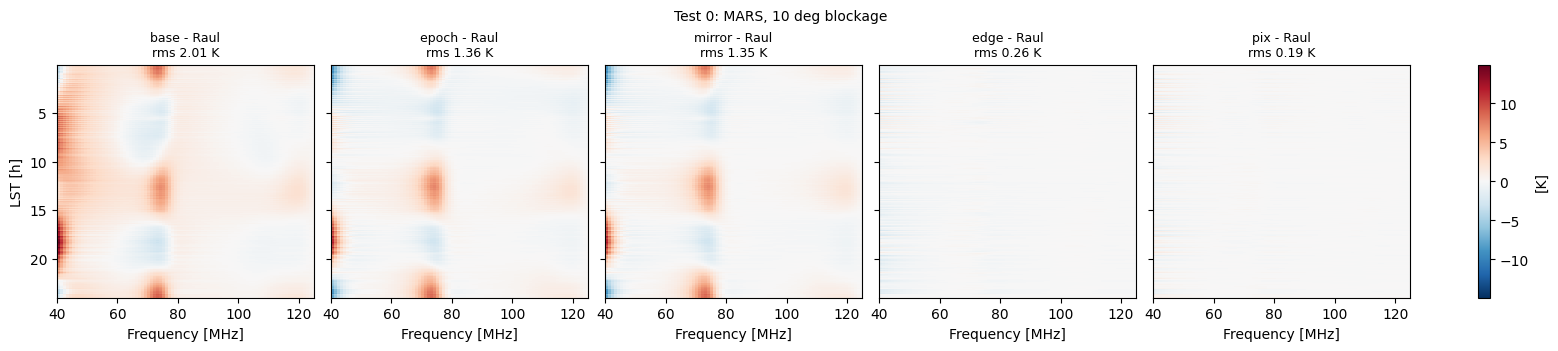

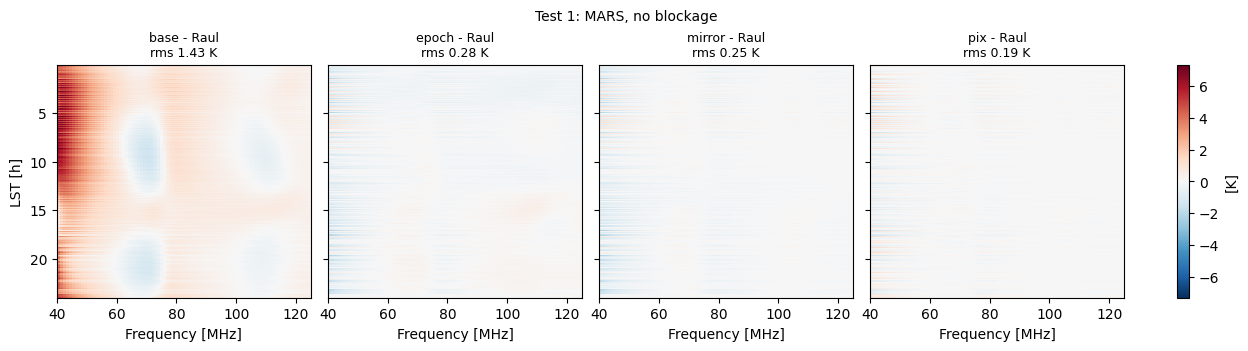

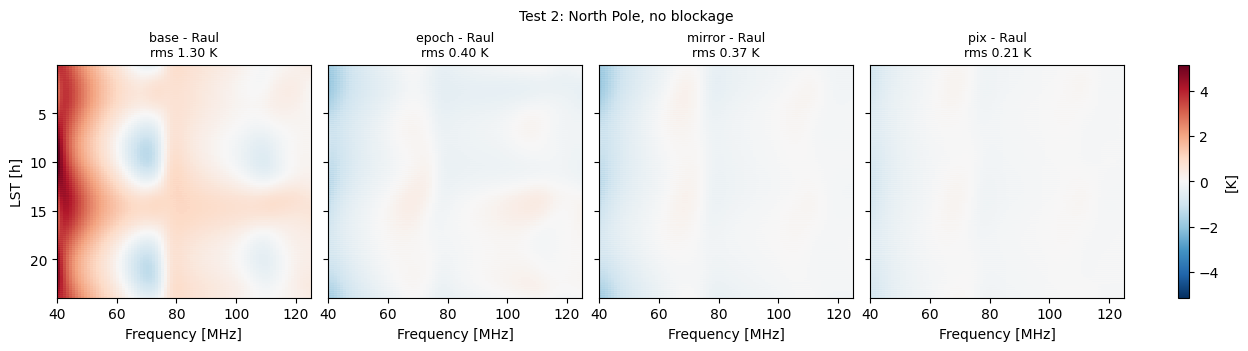

In [9]:
def resid_waterfalls(k, names, title):
    n = len(names)
    fig, axs = plt.subplots(
        1, n, figsize=(3.1 * n, 3.4), sharey=True,
        constrained_layout=True,
    )
    ds = [runs[(k, nm)] - raul[k] for nm in names]
    lim = max(np.max(np.abs(d)) for d in ds)
    ext = [freqs[0], freqs[-1], lsts[k][-1], lsts[k][0]]
    for ax, nm, d in zip(axs, names, ds):
        im = ax.imshow(d, extent=ext, aspect="auto", interpolation="none",
                       cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.set_title(f"{nm} - Raul\nrms {np.sqrt(np.mean(d**2)):.2f} K",
                     fontsize=9)
        ax.set_xlabel("Frequency [MHz]")
    axs[0].set_ylabel("LST [h]")
    fig.colorbar(im, ax=axs, label="[K]")
    fig.suptitle(title, fontsize=10)
    return fig


for k in TESTS:
    names = [n for n in ["base", "epoch", "mirror", "edge", "pix"]
             if (k, n) in runs]
    fig = resid_waterfalls(k, names, TESTS[k])
    savefig(fig, f"fig2_residual_waterfalls_test{k}.png")
    plt.show()

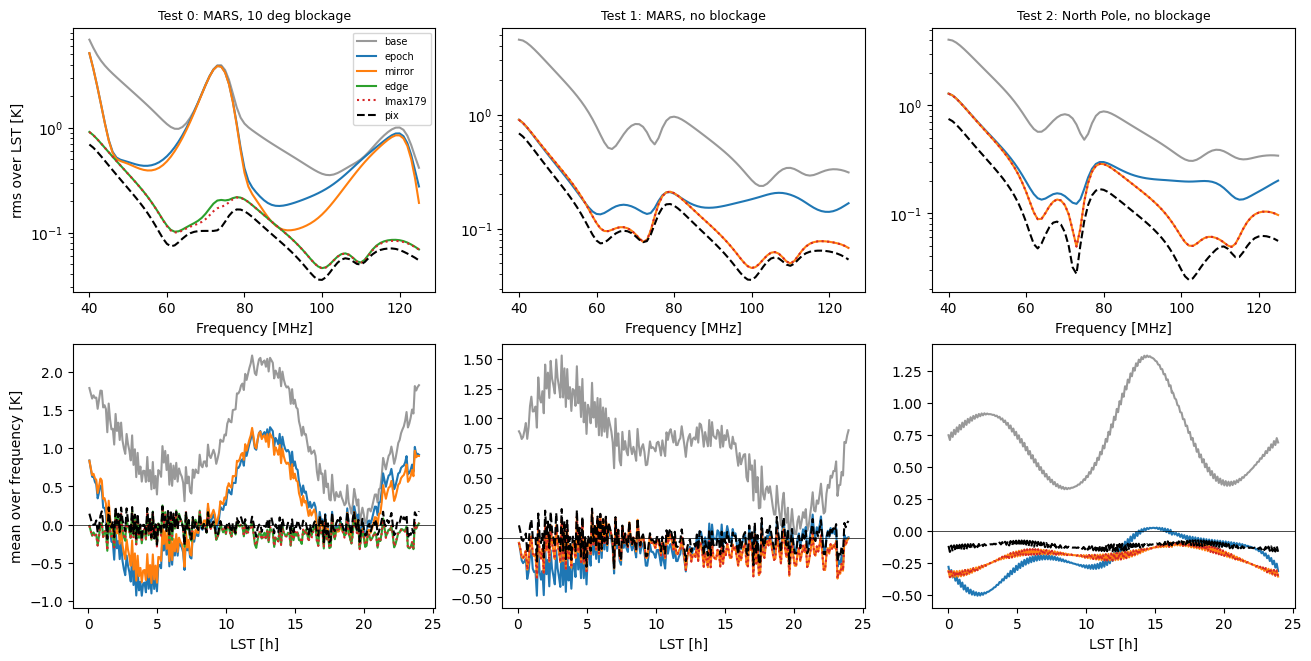

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6.5), constrained_layout=True)
sty = {"base": ("0.6", "-"), "epoch": ("C0", "-"), "mirror": ("C1", "-"),
       "edge": ("C2", "-"), "lmax179": ("C3", ":"), "pix": ("k", "--")}
for j, k in enumerate(TESTS):
    for nm, (c, ls) in sty.items():
        if (k, nm) not in runs:
            continue
        d = runs[(k, nm)] - raul[k]
        axs[0, j].plot(freqs, np.sqrt(np.mean(d**2, axis=0)), c=c, ls=ls,
                       label=nm)
        axs[1, j].plot(lsts[k], d.mean(axis=1), c=c, ls=ls, label=nm)
    axs[0, j].set_yscale("log")
    axs[0, j].set_title(TESTS[k], fontsize=9)
    axs[0, j].set_xlabel("Frequency [MHz]")
    axs[1, j].set_xlabel("LST [h]")
    axs[1, j].axhline(0, c="k", lw=0.5)
axs[0, 0].set_ylabel("rms over LST [K]")
axs[1, 0].set_ylabel("mean over frequency [K]")
axs[0, 0].legend(fontsize=7)
savefig(fig, "fig3_residual_structure.png")
plt.show()

## 5. Normalisation

**What mistsim divides by** (croissant v5.3.0.dev3 @ `58bf56e`, in the
venv's `site-packages/croissant/`):

- `Beam.compute_alm` (beam.py:184) transforms `data * horizon`: the
  blocked and below-horizon beam is zeroed before the harmonic
  transform.
- `Simulator.sim` (simulator.py:429-433) divides the convolution by
  `beam.compute_norm()` (beam.py:136-148), the integral of the
  **whole** beam over the sphere (`_compute_norm(use_horizon=False)`,
  beam.py:100-133, mwss quadrature weights), then adds
  `compute_fgnd() * Tgnd` (simulator.py:305-320), with
  `fgnd = 1 - int(B * horizon) / int(B)` (beam.py:150-166).
  mistsim's `Simulator` defaults to `Tgnd = 300` (sim.py:20).
- `croissant.simulator.correct_ground_loss(vis, fgnd, Tgnd)`
  (simulator.py:96-125) returns `(vis - fgnd * Tgnd) / (1 - fgnd)`.
  With the same `Tgnd` as the simulation this equals dividing the
  convolution by the **above-horizon** beam integral
  `int(B * horizon)`: Raul's sum(B T m) / sum(B m).
- `raul_comparison.ipynb` runs `Tgnd = 0` and then
  `correct_ground_loss(tant, fgnd, 0)`: it **already uses Raul's
  normalisation**.
- The pipeline's `simulate_waterfall` (pipeline.py:1705-1757) and the
  map-making operators normalise with
  `mapmaking.normalize_beam_alm(..., ground_loss=True)`
  (mapmaking.py:22-56, the `observation.ground_loss` default), i.e. by
  the full-sphere integral with no ground term: the blocked beam sees
  0 K. `ground_loss: false` selects the above-horizon integral.

For Tests 1 and 2 the beam is zero below theta = 90 deg (FEKO gives
gain 0 at the horizon and the file stops there), so `fgnd = 0` and
all normalisations coincide. Only Test 0 separates them.

In [11]:
for k in TESTS:
    f = fgnd[(k, "epoch")]
    print(f"{TESTS[k]:34s} fgnd: 40 MHz {f[0]:.4f}, 80 MHz {f[40]:.4f}, "
          f"125 MHz {f[-1]:.4f}")
# The algebra: full_sphere = above * (1 - fgnd); default adds 300 fgnd.
f0 = fgnd[(0, "epoch")][None, :]
alg_full = np.max(np.abs(runs[(0, "full_sphere")]
                         - runs[(0, "epoch")] * (1 - f0)))
alg_def = np.max(np.abs(runs[(0, "default")]
                        - (runs[(0, "epoch")] * (1 - f0) + 300 * f0)))
print(f"check full_sphere = above*(1-fgnd): {alg_full:.1e} K; "
      f"default = above*(1-fgnd) + 300 fgnd: {alg_def:.1e} K")

print(f"\n{'Test 0 normalisation':22s} {'mean':>8s} {'rms':>8s} "
      f"{'max|d|':>8s}")
norm_rows = {"above_horizon (Raul)": "epoch",
             "full_sphere (Tgnd=0)": "full_sphere",
             "default (Tgnd=300)": "default"}
for label, nm in norm_rows.items():
    s = stats(0, nm)
    summary[(0, nm)] = s
    print(f"{label:22s} {s['mean_K']:8.2f} {s['rms_K']:8.2f} "
          f"{s['max_abs_K']:8.2f}")

Test 0: MARS, 10 deg blockage      fgnd: 40 MHz 0.0174, 80 MHz 0.0091, 125 MHz 0.0105
Test 1: MARS, no blockage          fgnd: 40 MHz 0.0000, 80 MHz 0.0000, 125 MHz 0.0000
Test 2: North Pole, no blockage    fgnd: 40 MHz 0.0000, 80 MHz 0.0000, 125 MHz 0.0000
check full_sphere = above*(1-fgnd): 1.8e-12 K; default = above*(1-fgnd) + 300 fgnd: 1.8e-12 K

Test 0 normalisation       mean      rms   max|d|
above_horizon (Raul)       0.22     1.36    11.68
full_sphere (Tgnd=0)     -29.79    48.83   214.25
default (Tgnd=300)       -25.85    44.15   209.04


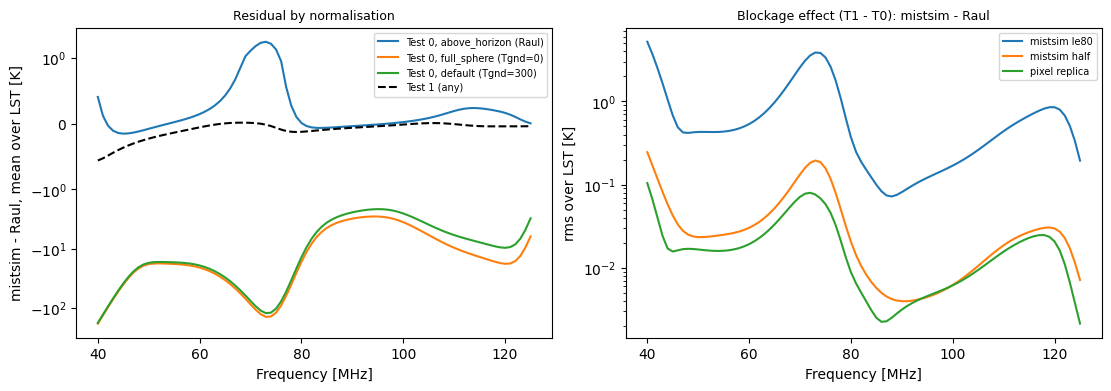

blockage effect, epoch : rms 1.355 K, max 11.80 K (effect itself: rms 11.7 K)
blockage effect, edge  : rms 0.066 K, max 0.89 K (effect itself: rms 11.7 K)
blockage effect, pix   : rms 0.030 K, max 0.32 K (effect itself: rms 11.7 K)


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for label, nm in norm_rows.items():
    d0 = runs[(0, nm)] - raul[0]
    axs[0].plot(freqs, d0.mean(axis=0), label=f"Test 0, {label}")
d1 = runs[(1, "epoch")] - raul[1]
axs[0].plot(freqs, d1.mean(axis=0), "k--", label="Test 1 (any)")
axs[0].set_yscale("symlog", linthresh=1)
axs[0].set_xlabel("Frequency [MHz]")
axs[0].set_ylabel("mistsim - Raul, mean over LST [K]")
axs[0].legend(fontsize=7)
axs[0].set_title("Residual by normalisation", fontsize=9)
# Blockage effect: (Test 1 - Test 0) in each simulator.
eff_r = raul[1] - raul[0]
for nm, lab in [("epoch", "mistsim le80"), ("edge", "mistsim half"),
                ("pix", "pixel replica")]:
    nm1 = "mirror" if nm == "edge" else nm
    eff_m = runs[(1, nm1)] - runs[(0, nm)]
    axs[1].plot(freqs, np.sqrt(np.mean((eff_m - eff_r) ** 2, axis=0)),
                label=lab)
axs[1].set_yscale("log")
axs[1].set_xlabel("Frequency [MHz]")
axs[1].set_ylabel("rms over LST [K]")
axs[1].set_title("Blockage effect (T1 - T0): mistsim - Raul", fontsize=9)
axs[1].legend(fontsize=7)
savefig(fig, "fig4_normalisation.png")
plt.show()
blk = {}
for nm, nm1 in [("epoch", "epoch"), ("edge", "mirror"), ("pix", "pix")]:
    d = (runs[(1, nm1)] - runs[(0, nm)]) - eff_r
    blk[nm] = rt.residual_stats(d)
    print(f"blockage effect, {nm:6s}: rms {blk[nm]['rms_K']:.3f} K, "
          f"max {blk[nm]['max_abs_K']:.2f} K "
          f"(effect itself: rms {np.sqrt(np.mean(eff_r**2)):.1f} K)")

## 6. Conventions: beam azimuth and the horizon mask

A synthetic, strongly asymmetric beam (`raul_tools.synthetic_beam`:
cos^2(theta) (1 + 0.8 sin(theta) cos(phi - 30 deg))) with a one-sided
mask (`synthetic_mask`: blocked for theta > 60 deg at beam-frame
0 <= phi < 90 deg) at 60 MHz, Test 1 site, every 8th of Raul's times.
mistsim is compared against the pixel-domain sum under four hypotheses:
the beam-frame azimuth is phi_b = AZ - rot (Raul's phi = AZ) or
phi_b = -(AZ - rot) (mirror), and the mask either rotates with the
beam or stays fixed on the ground. The masks are boolean on the beam
grid, so there is no degrees/radians ambiguity in `Beam`; the
pipeline's `horizon_max_theta` is in degrees and is converted with
`np.deg2rad` (pipeline.py:380), and beam files must store theta in
radians (checked at pipeline.py:373).

In [13]:
def synth_run():
    f1 = np.array([60.0])
    sky1 = rt.load_haslam(
        DATA_DIR
        / "20260215_for_christian/haslam408_ds_Remazeilles2014.fits",
        NSIDE, f1,
    )
    sel = order[1][::8]
    az, el = rt.pixel_altaz(NSIDE, locs[1], utc[1][sel])
    th = np.deg2rad(np.arange(181.0))
    ph = np.deg2rad(np.arange(360.0))
    g = rt.synthetic_beam(th[:, None], ph[None, :])[None]
    h = rt.synthetic_mask(th[:, None], ph[None, :])
    sm = ms.Sky(sky1, f1, sampling="healpix", coord="galactic")
    out = {}
    for rot in (0.0, 40.0):
        tant, _ = rt.run_mistsim(
            g, f1, sm, utc[1].jd, locs[1], horizon=h,
            beam_az_rot=rot, lmax=LMAX,
        )
        out[f"ms_rot{rot:.0f}"] = tant[sel, 0]
        for mir in (False, True):
            for mrot in (False, True):
                out[f"pix_rot{rot:.0f}_mir{int(mir)}_mrot{int(mrot)}"] = (
                    rt.analytic_pixel_convolution(
                        sky1[0], az, el, rot, mir, mrot
                    )
                )
    return out


syn = cached("synthetic_convention", synth_run)
conv = {}
print(f"{'beam_az_rot':>11s} {'phi_b':>14s} {'mask':>14s} "
      f"{'mean|d| K':>10s} {'max|d| K':>9s}")
for rot in (0, 40):
    for mir in (0, 1):
        for mrot in (0, 1):
            d = syn[f"ms_rot{rot}"] - syn[f"pix_rot{rot}_mir{mir}_mrot{mrot}"]
            key = (f"rot{rot}_" + ("phi=-(AZ-rot)" if mir else "phi=AZ-rot")
                   + ("_mask_rotates" if mrot else "_mask_fixed"))
            conv[key] = {"mean_abs_K": float(np.mean(np.abs(d))),
                         "max_abs_K": float(np.max(np.abs(d)))}
            print(f"{rot:11d} {'-(AZ-rot)' if mir else 'AZ-rot':>14s} "
                  f"{'rotates' if mrot else 'fixed':>14s} "
                  f"{conv[key]['mean_abs_K']:10.2f} "
                  f"{conv[key]['max_abs_K']:9.2f}")
print(f"(mean T_ant {np.mean(syn['ms_rot0']):.0f} K)")

beam_az_rot          phi_b           mask  mean|d| K  max|d| K
          0         AZ-rot          fixed     236.07    481.62
          0         AZ-rot        rotates     236.07    481.62
          0      -(AZ-rot)          fixed       2.22      7.11
          0      -(AZ-rot)        rotates       2.22      7.11
         40         AZ-rot          fixed     259.88    446.88
         40         AZ-rot        rotates     243.96    474.22
         40      -(AZ-rot)          fixed      36.89     80.55
         40      -(AZ-rot)        rotates       3.13     11.04
(mean T_ant 3854 K)


## 7. Residual budget and outputs

In [14]:
# Where the remaining residual sits: mistsim (best configuration)
# against the pixel replica, and the replica against Raul.
BEST = {0: "edge", 1: "mirror", 2: "mirror"}
split = {}
for k in TESTS:
    a = rt.residual_stats(runs[(k, BEST[k])] - runs[(k, "pix")])
    b = rt.residual_stats(runs[(k, "pix")] - raul[k])
    split[f"test{k}"] = {
        "best_variant": BEST[k],
        "mistsim_minus_replica": a,
        "replica_minus_raul": b,
    }
    print(f"{TESTS[k]:34s}")
    for lab, s in (("mistsim - replica", a), ("replica - Raul", b)):
        print(f"    {lab:18s} mean {s['mean_K']:6.3f}  rms "
              f"{s['rms_K']:.3f}  max|d| {s['max_abs_K']:.2f} K")

Test 0: MARS, 10 deg blockage     
    mistsim - replica  mean -0.088  rms 0.173  max|d| 1.77 K
    replica - Raul     mean -0.003  rms 0.195  max|d| 1.94 K
Test 1: MARS, no blockage         
    mistsim - replica  mean -0.081  rms 0.160  max|d| 0.84 K
    replica - Raul     mean -0.011  rms 0.193  max|d| 1.87 K
Test 2: North Pole, no blockage   
    mistsim - replica  mean -0.084  rms 0.171  max|d| 0.97 K
    replica - Raul     mean -0.118  rms 0.213  max|d| 0.97 K


In [15]:
# Ground fraction of Test 0's beam for the three edge treatments.
fgnd_masks = {}
for nm, lab in (("mirror", "theta <= 80 (edge ~80.5)"),
                ("edge", "theta = 80 at weight 0.5"),
                ("edge_lt80", "theta < 80 (edge ~79.5)")):
    f = fgnd[(0, nm)]
    fgnd_masks[nm] = {f"{fr:.0f}MHz": float(v)
                      for fr, v in zip(freqs[[0, 40, 85]], f[[0, 40, 85]])}
    print(f"{lab:26s} fgnd: 40 MHz {f[0]:.4f}, 80 MHz {f[40]:.4f}, "
          f"125 MHz {f[-1]:.4f}")

theta <= 80 (edge ~80.5)   fgnd: 40 MHz 0.0174, 80 MHz 0.0091, 125 MHz 0.0105
theta = 80 at weight 0.5   fgnd: 40 MHz 0.0197, 80 MHz 0.0105, 125 MHz 0.0118
theta < 80 (edge ~79.5)    fgnd: 40 MHz 0.0221, 80 MHz 0.0119, 125 MHz 0.0130


In [16]:
def jkey(k, nm):
    return f"test{k}/{nm}"


out_json = {
    "provenance": PROV,
    "beam_check": beam_check,
    "raul_time_grid": {
        "utc_start": utc[0][0].isot, "step_s": rt.RAUL_STEP_S,
        "n": int(rt.RAUL_NSTEP),
        "lst": "apparent, IAU2006A, DUT1 = 0, sorted",
    },
    "fgnd_test0": {f"{f:.0f}MHz": float(v) for f, v in
                   zip(freqs[[0, 40, 85]], fgnd[(0, "epoch")][[0, 40, 85]])},
    "residual_mistsim_minus_raul": {jkey(k, nm): s
                                    for (k, nm), s in summary.items()},
    "blockage_effect_residual": blk,
    "convention_test": conv,
    "residual_split": split,
    "fgnd_test0_by_edge": fgnd_masks,
    "residual_profiles": {
        jkey(k, nm): {
            "rms_vs_freq_K": np.sqrt(
                np.mean((runs[(k, nm)] - raul[k]) ** 2, axis=0)
            ).round(4).tolist(),
            "mean_vs_lst_K": (runs[(k, nm)] - raul[k]).mean(axis=1)
            .round(4).tolist(),
        }
        for k in TESTS for nm in ("base", "epoch", "mirror", "edge", "pix")
        if (k, nm) in runs
    },
    "freqs_MHz": freqs.tolist(),
    "lst_h": {f"test{k}": lsts[k].round(6).tolist() for k in TESTS},
}
(RES / "summary.json").write_text(json.dumps(out_json, indent=1))
print("wrote", (RES / "summary.json").relative_to(REPO))
for p in sorted(RES.glob("*.png")):
    print("wrote", p.relative_to(REPO), f"{p.stat().st_size / 1e3:.0f} kB")

wrote notebooks/sim_comparisons/results_normalization/summary.json
wrote notebooks/sim_comparisons/results_normalization/fig1_data_waterfalls_spectra.png 114 kB
wrote notebooks/sim_comparisons/results_normalization/fig2_residual_waterfalls_test0.png 91 kB
wrote notebooks/sim_comparisons/results_normalization/fig2_residual_waterfalls_test1.png 81 kB
wrote notebooks/sim_comparisons/results_normalization/fig2_residual_waterfalls_test2.png 74 kB
wrote notebooks/sim_comparisons/results_normalization/fig3_residual_structure.png 209 kB
wrote notebooks/sim_comparisons/results_normalization/fig4_normalisation.png 71 kB


## Summary

Residual mistsim - Raul in K (mean / rms / max |d| over 241 LST x 86
frequencies), from the tables above:

| Run | Test 0 (10 deg blockage) | Test 1 (MARS) | Test 2 (North Pole) |
|---|---|---|---|
| `base` (= `raul_comparison.ipynb`) | 1.07 / 2.01 / 14.9 | 0.75 / 1.43 / 7.3 | 0.72 / 1.30 / 5.1 |
| `epoch` (Raul's UTC grid) | 0.22 / 1.36 / 11.7 | -0.09 / 0.28 / 2.3 | -0.20 / 0.40 / 1.9 |
| `mirror` (+ beam gain(-phi)) | 0.22 / 1.35 / 11.7 | -0.09 / 0.26 / 2.3 | -0.20 / 0.37 / 1.9 |
| `edge` (+ half-weight edge row) | -0.09 / 0.26 / 2.4 | (no edge) | (no edge) |
| pixel replica of Raul's code | -0.00 / 0.19 / 1.9 | -0.01 / 0.19 / 1.9 | -0.12 / 0.21 / 1.0 |

1. **Raul's normalisation is already mistsim's above-horizon
   normalisation** (`Simulator.sim` with `Tgnd = 0`, then
   `correct_ground_loss(T, fgnd, 0)`), which `raul_comparison.ipynb`
   used. It does not explain the residual. The other two options miss
   by -30 K mean and 214 K max on Test 0 (full-sphere norm, blocked
   beam at 0 K, as the pipeline's `simulate_waterfall` does) or -26 K
   mean and 209 K max (`Tgnd = 300 K`, mistsim's default); on Tests 1
   and 2 all three coincide (`fgnd = 0`).
2. **The ~1 K residual had two causes:** the epoch (the old notebook
   placed Raul's LSTs in 2022; his grid is UTC 2014-01-01 09:29:45 +
   i x 359 s), and for Test 0 the half-degree position of the mask edge
   on mistsim's 1-deg beam grid. Fixing both leaves 0.26, 0.26 and
   0.37 K rms (2-4e-5 of T_ant), max 2.4 K at 40 MHz.
3. **What is left** splits into mistsim - replica (rms 0.16-0.17 K,
   mean -0.08 K) and replica - Raul (rms 0.19-0.21 K, frequency-
   structured, largest at 40 MHz). The second is a detail of Raul's
   2026 code that his 2022 code does not show; the FEKO file's printed
   precision (4-decimal dB, 4-digit fields) is a candidate.
4. **Conventions** (section 6): with `beam_az_rot = 0` mistsim puts beam
   phi = 0 at North and phi = 90 deg at **West** (right-handed with z up);
   Raul maps phi onto AZ (N through E), the mirror image. The `horizon`
   mask lives in the beam frame: it is mirrored the same way and
   **rotates with `beam_az_rot`**. A terrain horizon given in
   astronomical azimuth must be passed as mask(theta, phi_b) with
   phi_b = -(AZ - beam_az_rot).

See `NORMALIZATION_REPORT.md` for the implications and next steps.